# France and Brazil: reconstruct the samples and explore the fitted maps

Run all cells in a fresh kernel to reconstruct both country samples and regenerate coordinates, metrics and training curves. **`REFIT = False` loads the supplied country fits without training.** With `REFIT = True`, each country is trained separately for the fixed number of epochs. Refit mode replaces its outputs, so use a different `OUTPUT` directory for experiments.

**Inputs:** `data/raw/france_participation.csv`, `brazil_participation.csv`, and `data/processed/participant_age_decisions.csv` from notebook 01. Saved-fit mode also reads `outputs/models/{france,brazil}/` and the country training histories in `outputs/tables/`. All are supplied, so preceding notebooks need not run first.

**Outputs:** filtered `{country}_pairwise.parquet` in `data/processed/`, coordinates and model summaries in `outputs/models/` and `outputs/tables/`, and historical training curves in `outputs/figures/`. The figure and external-validation notebooks use these outputs.

Participants with unspecified age remain eligible. Excluded participants contribute no choices. Demographic variables and ideological labels never enter model fitting. The two countries have separate latent spaces, so their coordinate distances cannot support cross-country polarization comparisons.

The model settings below expose the head choice. The intermediate head guarantees preference for the closer proposal and A/B exchange symmetry, while allowing a flexible positive distance multiplier. It does not constrain the partial derivatives of the choice probability. The [8, 8] head used by the paper has 105 parameters, [3] has 13, and the original head has 20 in two dimensions, excluding embeddings.


In [1]:
from pathlib import Path
import json
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import tensorflow as tf

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."
sys.path.insert(0, str(ROOT / "src"))
from choice_models import build_choice_model

assert tf.__version__.startswith(
    "2.15."
), "Use TensorFlow 2.15, as specified in requirements.txt."
PROCESSED = ROOT / "data/processed"
OUTPUT = ROOT / "outputs"
for folder in [
    PROCESSED,
    OUTPUT / "models",
    OUTPUT / "diagnostics",
    OUTPUT / "figures",
    OUTPUT / "tables",
]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

import math

# False reloads the included manuscript fit. True trains a new fit and replaces
# its weights, coordinates and history in OUTPUT. Change OUTPUT to keep experiments separate.
REFIT = False
VARIANT = "intermediate"  # "original" selects the fully flexible head.
HIDDEN_SIZES = [8, 8]  # [3] selects the compact 13-parameter intermediate head.
MINIMUM_SCALE = 1e-6  # Positive floor for the intermediate distance multiplier.
MODEL_SETTINGS = dict(variant=VARIANT, hidden_sizes=HIDDEN_SIZES, minimum_scale=MINIMUM_SCALE)
EPOCHS = 20  # Always use the final epoch, not the best held-out epoch.
BATCH_SIZE = 64
LEARNING_RATE = 0.01  # Adamax learning rate.
STEPS_PER_EXECUTION = 64  # Groups graph execution calls, not optimizer updates.
DEVICE = "/CPU:0"

DIMENSION = 2
EMBEDDING_SEED = 101
COUNTRIES = {
    "france": {
        "seed": 301,
        "historical_rows": 2_055_268,
        "historical_users": 1_488,
        "historical_proposals": 120,
    },
    "brazil": {
        "seed": 101,
        "historical_rows": 169_258,
        "historical_users": 790,
        "historical_proposals": 67,
    },
}
# Country seeds govern the choice head, global stream and the historical A/B swaps.
# Both countries retain embedding seed 101, including France's seed-301 head.
age_decisions = pd.read_csv(PROCESSED / "participant_age_decisions.csv", dtype={"uuid": str})
age_decisions["country"] = (
    age_decisions["country"].str.casefold().replace({"francia": "france", "brasil": "brazil"})
)
assert not age_decisions.duplicated(["country", "uuid"]).any()
assert age_decisions["include"].isin([True, False]).all()


## Reconstruct the historical samples and apply the age decisions

The minimum of ten recorded comparisons is applied before repeated participant–proposal pairs are collapsed, as in the original notebooks. The most recent non-missing pair is retained, and records with `selected == 0` are removed. The original row order is retained for the subsequent split. Sample-size and participant checks make a different source file fail visibly instead of silently producing another analysis.

The age decision is applied by participant ID to all their retained records. No demographic inner join is used to select the training sample. The included age-decision table must account for every historical participant, including those without metadata.


In [2]:
samples = {}
audit_rows = []
for country, settings in COUNTRIES.items():
    data = pd.read_csv(ROOT / "data" / "raw" / f"{country}_participation.csv")
    raw_rows = len(data)
    data = data.reset_index().rename(columns={"index": "id_original"})
    data["created_at"] = pd.to_datetime(data["created_at"].str[:19], format="%Y-%m-%d %H:%M:%S")
    data = data.sort_values("created_at")

    # Preserve the historical 50% alternative-position randomization.
    np.random.seed(settings["seed"])
    swapped_ids = np.random.choice(data.index, size=int(len(data) * 0.5), replace=False)
    swapped = data.loc[swapped_ids].copy()
    swapped[["option_a", "option_b"]] = swapped[["option_b", "option_a"]].to_numpy()
    data.loc[swapped_ids] = swapped
    data = data[data.option_a.notna() & data.option_b.notna()].reset_index(drop=True)
    data[["option_a", "option_b", "selected"]] = data[
        ["option_a", "option_b", "selected"]
    ].astype(int)
    counts = data.groupby("user_id")["id_original"].count()
    data = data[data.user_id.isin(counts[counts >= 10].index)].copy()

    a = data[["option_a", "option_b"]].to_numpy()
    data["option_a_sorted"] = np.minimum(a[:, 0], a[:, 1])
    data["option_b_sorted"] = np.maximum(a[:, 0], a[:, 1])
    # A fixed-width code gives each unordered policy pair one deduplication key.
    data["card_id"] = (
        "1"
        + data.option_a_sorted.astype(str).str.zfill(3)
        + data.option_b_sorted.astype(str).str.zfill(3)
    ).astype(int)
    data = data.sort_values(["id_original", "created_at"])
    latest = data[["user_id", "card_id", "created_at", "id_original"]]
    latest = (
        latest.groupby(["created_at", "user_id", "card_id", "id_original"])
        .count()
        .reset_index()
    )
    latest = latest.drop_duplicates(["user_id", "card_id"], keep="last")
    data = data[data.id_original.isin(latest.id_original)].copy()
    data = data[(data.selected != 0) & data.user_id.notna()].copy()
    data["user_id"] = data.user_id.astype(str)
    n_proposals = len(set(data.option_a) | set(data.option_b))
    assert (len(data), data.user_id.nunique(), n_proposals) == (
        settings["historical_rows"],
        settings["historical_users"],
        settings["historical_proposals"],
    ), country
    assert data.selected.isin(set(data.option_a) | set(data.option_b)).all()
    assert ((data.selected == data.option_a) | (data.selected == data.option_b)).all()

    decisions = age_decisions[age_decisions.country == country].set_index("uuid")
    historical_ids = set(data.user_id)
    assert historical_ids.issubset(
        set(decisions.index)
    ), "Age decisions are missing participant IDs"
    included_ids = set(decisions.index[decisions.include])
    excluded_ids = historical_ids - included_ids
    removed_rows = int(data.user_id.isin(excluded_ids).sum())
    sample = data[data.user_id.isin(included_ids)][
        ["id_original", "user_id", "option_a", "option_b", "selected", "created_at"]
    ].reset_index(drop=True)
    assert not sample.user_id.isin(excluded_ids).any()
    assert len(sample) + removed_rows == settings["historical_rows"]
    assert len(set(sample.option_a) | set(sample.option_b)) == settings["historical_proposals"]
    samples[country] = sample
    audit_rows.append(
        {
            "country": country,
            "raw_rows": raw_rows,
            "historical_users": settings["historical_users"],
            "historical_rows": settings["historical_rows"],
            "excluded_users": len(excluded_ids),
            "excluded_rows": removed_rows,
            "retained_users": sample.user_id.nunique(),
            "retained_rows": len(sample),
            "proposals": n_proposals,
        }
    )

sample_audit = pd.DataFrame(audit_rows)
display(sample_audit)
sample_audit.to_csv(OUTPUT / "tables" / "france_brazil_age_sample_audit.csv", index=False)
sample_audit.to_latex(OUTPUT / "tables" / "france_brazil_age_sample_audit.tex", index=False)
for country, sample in samples.items():
    display(sample)
    sample.to_parquet(ROOT / "data" / "processed" / f"{country}_pairwise.parquet", index=False)


,country,raw_rows,historical_users,historical_rows,excluded_users,excluded_rows,retained_users,retained_rows,proposals
0,france,2089561,1488,2055268,45,71628,1443,1983640,120
1,brazil,187009,790,169258,25,5455,765,163803,67


,id_original,user_id,option_a,option_b,selected,created_at
0,0,001b18de-e566-4b13-9cf3-33e22e32be2a,23,55,23,2022-04-06 13:37:10
1,1,001b18de-e566-4b13-9cf3-33e22e32be2a,30,23,23,2022-04-06 13:45:03
2,2,001b18de-e566-4b13-9cf3-33e22e32be2a,15,23,23,2022-04-06 13:45:03
3,3,001b18de-e566-4b13-9cf3-33e22e32be2a,37,23,23,2022-04-06 13:45:03
4,4,001b18de-e566-4b13-9cf3-33e22e32be2a,23,7,23,2022-04-06 13:45:54
...,...,...,...,...,...,...
1983635,2089556,23dc2d73-ff4b-4b6b-b4fb-35380d616e18,65,25,25,2022-06-01 11:01:30
1983636,2089557,23dc2d73-ff4b-4b6b-b4fb-35380d616e18,18,25,25,2022-06-01 11:01:30
1983637,2089558,23dc2d73-ff4b-4b6b-b4fb-35380d616e18,40,65,40,2022-06-01 11:01:30
1983638,2089559,23dc2d73-ff4b-4b6b-b4fb-35380d616e18,18,40,40,2022-06-01 11:01:30


,id_original,user_id,option_a,option_b,selected,created_at
0,0,004ddaed-61da-408f-9030-79728dd9acfa,38,1,38,2022-09-28 17:34:37
1,1,004ddaed-61da-408f-9030-79728dd9acfa,1,7,7,2022-09-28 17:34:37
2,2,004ddaed-61da-408f-9030-79728dd9acfa,1,47,47,2022-09-28 17:34:37
3,3,004ddaed-61da-408f-9030-79728dd9acfa,61,1,61,2022-09-28 17:34:37
4,4,004ddaed-61da-408f-9030-79728dd9acfa,22,1,22,2022-09-28 17:34:37
...,...,...,...,...,...,...
163798,178649,57b51465-dd99-4109-8dc2-c1fd0c914299,24,5,24,2022-11-07 14:36:13
163799,178650,57b51465-dd99-4109-8dc2-c1fd0c914299,25,24,24,2022-11-07 14:36:13
163800,178651,57b51465-dd99-4109-8dc2-c1fd0c914299,29,5,29,2022-11-07 14:36:13
163801,178652,57b51465-dd99-4109-8dc2-c1fd0c914299,29,25,29,2022-11-07 14:36:13


## Build the split, load or train, and evaluate each country

IDs are mapped to contiguous embedding rows in sorted order. The first floor(90% × comparisons) within each participant goes to training, in retained source order. A singleton contributes its only comparison to training. The split is not shuffled. Training batches are shuffled each epoch, and incomplete final batches are retained.

Each loop below shows the full procedure for a country. The generated model specification and sorted ID lists must match the supplied fit in saved-fit mode. Training-history curves and duration then describe that original training, while coordinates and final metrics are computed from the loaded weights. New training uses only the fixed final epoch, with no held-out checkpoint selection.


Model: "dynamap_intermediate"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 political_coords (Politica  (1, 6)                    3126      


 lCoords)                                                        


...

Trainable params: 3231 (12.62 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


france: loaded the supplied fit, with its original training history and duration.


,country,loss,accuracy,val_loss,val_accuracy,epoch
0,france,0.305931,0.867680,0.758132,0.621686,1
1,france,0.269856,0.882748,0.768993,0.625661,2
2,france,0.267816,0.883846,0.764337,0.626952,3
3,france,0.267237,0.884060,0.778901,0.629088,4
4,france,0.267120,0.884245,0.760687,0.628756,5
5,france,0.267228,0.884176,0.757272,0.627957,6
6,france,0.267380,0.884301,0.765554,0.628540,7
7,france,0.267554,0.884186,0.749631,0.628354,8
8,france,0.267579,0.884129,0.758464,0.627952,9
9,france,0.267750,0.884024,0.770051,0.628133,10


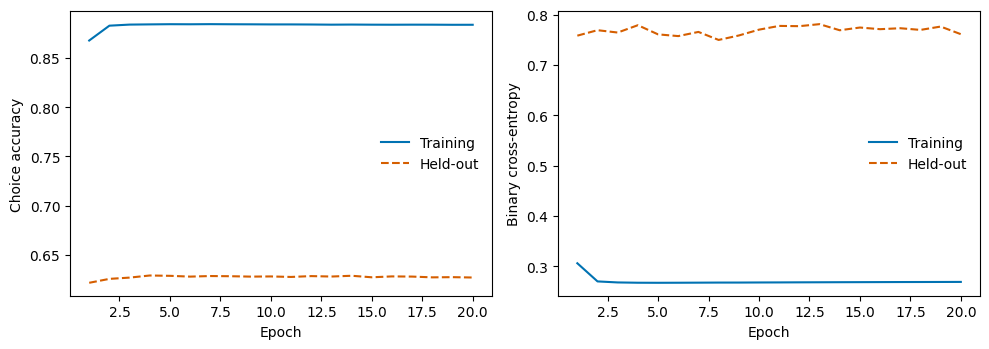

,user_id,z1,z2
0,001b18de-e566-4b13-9cf3-33e22e32be2a,0.638296,2.742960e-01
1,002323cc-f7bd-4c3b-b3a7-d909a4b48556,0.539659,3.823855e-01
2,0062701e-ba6f-420c-851c-a54557cad396,0.460885,6.715837e-01
3,007fb7f8-afde-4779-8fd9-191083118401,0.758623,4.740771e-07
4,0084be50-21a7-47bd-a21c-e917bb93969c,0.468171,4.531662e-01
...,...,...,...
1438,ff53f691-1512-46d4-b81d-15e0ff28ca8d,0.709750,1.082236e-03
1439,ff6f2650-d569-46e0-8ff2-2530cb6cd57d,0.232620,5.176508e-01
1440,ff7ee3e1-a916-4f4c-bc12-f3c9fc293e4c,0.499971,4.392747e-01
1441,ff8b80f1-5ca1-4bf6-9dd5-f2c14047f507,0.347375,9.649134e-02


,option_id,z1,z2
0,1,0.830444,0.526552
1,2,0.205878,0.236614
2,3,0.642222,0.904915
3,4,0.955556,0.703897
4,5,0.923359,0.630182
...,...,...,...
115,116,0.169618,0.449608
116,117,0.111106,0.384610
117,118,0.103935,0.505886
118,119,0.317887,0.359360


{'dimension': 2,
 'embedding_seed': 101,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 120,
 'n_users': 1443,
 'seed': 301,
 'variant': 'intermediate'}

,user_id,n_choices
0,001b18de-e566-4b13-9cf3-33e22e32be2a,2288
1,002323cc-f7bd-4c3b-b3a7-d909a4b48556,1382
2,0062701e-ba6f-420c-851c-a54557cad396,600
3,007fb7f8-afde-4779-8fd9-191083118401,2413
4,0084be50-21a7-47bd-a21c-e917bb93969c,1011
...,...,...
1438,ff53f691-1512-46d4-b81d-15e0ff28ca8d,452
1439,ff6f2650-d569-46e0-8ff2-2530cb6cd57d,15
1440,ff7ee3e1-a916-4f4c-bc12-f3c9fc293e4c,1934
1441,ff8b80f1-5ca1-4bf6-9dd5-f2c14047f507,42


,country,n_users,n_proposals,n_records,training_rows,held_out_rows,evaluated_held_out_rows,singleton_users_in_training,global_seed,branch_seed,...,test_loss,test_accuracy,train_loss,train_accuracy,fit_seconds,architecture,model_configuration,checkpoint_selection,tensorflow,parameters
0,france,1443,120,1983640,1784636,199004,199004,0,301,301,...,0.761075,0.627043,0.268078,0.883977,192.033746,intermediate,"{'variant': 'intermediate', 'hidden_sizes': [8...",fixed_final_epoch,2.15.1,3231


...

Trainable params: 1769 (6.91 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


brazil: loaded the supplied fit, with its original training history and duration.


,country,loss,accuracy,val_loss,val_accuracy,epoch
0,brazil,0.435537,0.810266,0.773780,0.589148,1
1,brazil,0.331067,0.852249,0.747672,0.612206,2
2,brazil,0.296986,0.866987,0.740717,0.618914,3
3,brazil,0.288355,0.871535,0.746271,0.622627,4
4,brazil,0.284791,0.872718,0.733707,0.624184,5
5,brazil,0.283066,0.873683,0.747190,0.623046,6
6,brazil,0.281913,0.874825,0.742705,0.625621,7
7,brazil,0.281041,0.874444,0.752048,0.627718,8
8,brazil,0.280544,0.875178,0.740800,0.626460,9
9,brazil,0.279953,0.875097,0.745202,0.626939,10


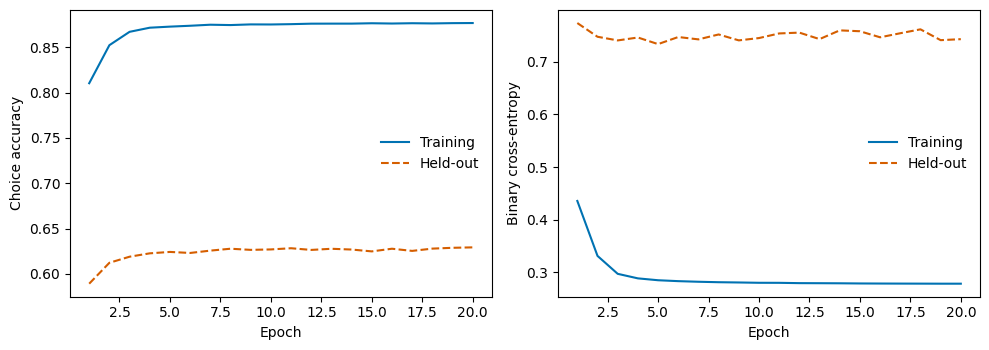

,user_id,z1,z2
0,004ddaed-61da-408f-9030-79728dd9acfa,0.614649,0.329158
1,008945db-7336-4b6f-80c8-67f6f760146a,0.603311,0.459762
2,00f4f1e4-90a3-41ee-a0dc-b0fe3a824688,0.497200,0.506703
3,01048f40-73fa-460a-8a0f-d37f46ba2bf0,0.540310,0.481194
4,015ea9da-e6d4-4902-990e-298155884106,0.365017,0.535492
...,...,...,...
760,fe7adca8-9f18-4048-bd9a-a0d1c7636378,0.418282,0.515607
761,fe8ee69a-b37b-4e1b-be58-9391d29f0727,0.289338,0.258464
762,fecc1142-5009-42bc-b2c8-389c77e7b1fd,0.498278,0.477491
763,fed0ccb0-fdf8-423a-abd1-cef80cc4d6c5,0.667909,0.484973


,option_id,z1,z2
0,1,0.158468,0.732181
1,2,0.628181,0.719921
2,3,0.730366,0.265257
3,4,0.698903,0.409594
4,5,0.696382,0.377449
...,...,...,...
62,63,0.554026,0.335928
63,65,0.596552,0.266331
64,66,0.513765,0.764957
65,67,0.450624,0.592414


{'dimension': 2,
 'embedding_seed': 101,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 67,
 'n_users': 765,
 'seed': 101,
 'variant': 'intermediate'}

,user_id,n_choices
0,004ddaed-61da-408f-9030-79728dd9acfa,51
1,008945db-7336-4b6f-80c8-67f6f760146a,422
2,00f4f1e4-90a3-41ee-a0dc-b0fe3a824688,3
3,01048f40-73fa-460a-8a0f-d37f46ba2bf0,66
4,015ea9da-e6d4-4902-990e-298155884106,835
...,...,...
760,fe7adca8-9f18-4048-bd9a-a0d1c7636378,65
761,fe8ee69a-b37b-4e1b-be58-9391d29f0727,172
762,fecc1142-5009-42bc-b2c8-389c77e7b1fd,29
763,fed0ccb0-fdf8-423a-abd1-cef80cc4d6c5,83


,country,n_users,n_proposals,n_records,training_rows,held_out_rows,evaluated_held_out_rows,singleton_users_in_training,global_seed,branch_seed,...,test_loss,test_accuracy,train_loss,train_accuracy,fit_seconds,architecture,model_configuration,checkpoint_selection,tensorflow,parameters
0,brazil,765,67,163803,147106,16697,16697,2,101,101,...,0.743122,0.629215,0.275662,0.878034,17.441809,intermediate,"{'variant': 'intermediate', 'hidden_sizes': [8...",fixed_final_epoch,2.15.1,1769


,country,n_users,n_proposals,n_records,training_rows,held_out_rows,evaluated_held_out_rows,singleton_users_in_training,global_seed,branch_seed,...,test_loss,test_accuracy,train_loss,train_accuracy,fit_seconds,architecture,model_configuration,checkpoint_selection,tensorflow,parameters
0,france,1443,120,1983640,1784636,199004,199004,0,301,301,...,0.761075,0.627043,0.268078,0.883977,192.033746,intermediate,"{'variant': 'intermediate', 'hidden_sizes': [8...",fixed_final_epoch,2.15.1,3231
1,brazil,765,67,163803,147106,16697,16697,2,101,101,...,0.743122,0.629215,0.275662,0.878034,17.441809,intermediate,"{'variant': 'intermediate', 'hidden_sizes': [8...",fixed_final_epoch,2.15.1,1769


In [3]:
fit_summaries = []
for country, settings in COUNTRIES.items():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(settings["seed"])
    sample = samples[country]
    # ID order fixes which person/proposal occupies each embedding row.
    proposal_ids = sorted(set(sample.option_a) | set(sample.option_b))
    participant_ids = sorted(sample.user_id.unique())
    proposal_index = {value: index for index, value in enumerate(proposal_ids)}
    participant_index = {value: index for index, value in enumerate(participant_ids)}
    X = np.column_stack(
        [
            sample.option_a.map(proposal_index),
            sample.user_id.map(participant_index),
            sample.option_b.map(proposal_index),
        ]
    ).astype(np.int32)
    y = (sample.selected == sample.option_a).to_numpy(dtype=np.float32)
    # Assign singletons to training so no exported coordinate remains untrained.
    train_indices, test_indices = [], []
    for _, participant_rows in sample.groupby("user_id", sort=True):
        indices = participant_rows.index.to_numpy()
        cutoff = 1 if len(indices) == 1 else int(len(indices) * 0.9)
        train_indices.extend(indices[:cutoff])
        test_indices.extend(indices[cutoff:])
    train_indices = np.asarray(train_indices, dtype=np.int64)
    test_indices = np.asarray(test_indices, dtype=np.int64)
    assert len(train_indices) + len(test_indices) == len(sample)
    assert len(np.intersect1d(train_indices, test_indices)) == 0
    assert set(X[train_indices, 1]) == set(range(len(participant_ids)))
    expected_test_users = {
        participant_index[u]
        for u, count in sample.groupby("user_id").size().items()
        if count >= 2
    }
    assert set(X[test_indices, 1]) == expected_test_users

    train = tf.data.Dataset.from_tensor_slices((X[train_indices], y[train_indices]))
    train = train.shuffle(len(train_indices)).batch(BATCH_SIZE, drop_remainder=False).repeat()
    held_out = tf.data.Dataset.from_tensor_slices((X[test_indices], y[test_indices]))
    held_out = held_out.batch(BATCH_SIZE, drop_remainder=False).repeat()
    model = build_choice_model(
        n_options=len(proposal_ids),
        n_users=len(participant_ids),
        dimension=DIMENSION,
        seed=settings["seed"],
        embedding_seed=EMBEDDING_SEED,
        **MODEL_SETTINGS,
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=["accuracy"],
        steps_per_execution=STEPS_PER_EXECUTION,
    )
    model.summary()
    destination = OUTPUT / "models" / country
    destination.mkdir(parents=True, exist_ok=True)
    model_specification = json.loads(model.choice_configuration_json)
    if REFIT:
        started = time.perf_counter()
        with tf.device(DEVICE):
            history = model.fit(
                train,
                epochs=EPOCHS,
                steps_per_epoch=math.ceil(len(train_indices) / BATCH_SIZE),
                validation_data=held_out,
                validation_steps=math.ceil(len(test_indices) / BATCH_SIZE),
                verbose=2,
            )
        elapsed = time.perf_counter() - started
        values = pd.DataFrame(history.history).rename_axis("epoch_zero_based").reset_index()
        values["epoch"] = values.pop("epoch_zero_based") + 1
        values.insert(0, "country", country)
    else:
        saved_specification = json.loads((destination / "model_specification.json").read_text())
        assert (
            model_specification == saved_specification
        ), "Requested model differs from the supplied fit. Use REFIT=True."
        assert (
            pd.read_csv(destination / "coordsU.csv", dtype={"user_id": str}).user_id.tolist()
            == participant_ids
        )
        assert pd.read_csv(destination / "coordsP.csv").option_id.tolist() == proposal_ids
        model.load_weights(str(destination / "model.weights.h5"))
        values = pd.read_csv(OUTPUT / "tables" / f"{country}_training_history.csv")
        saved_properties = json.loads((destination / "model_properties.json").read_text())
        elapsed = float(saved_properties["fit_seconds"])
        print(
            f"{country}: loaded the supplied fit, with its original training history and duration."
        )

    # Finite, non-repeating datasets evaluate every row exactly once.
    final_test = tf.data.Dataset.from_tensor_slices((X[test_indices], y[test_indices])).batch(
        BATCH_SIZE
    )
    final_train = tf.data.Dataset.from_tensor_slices(
        (X[train_indices], y[train_indices])
    ).batch(BATCH_SIZE)
    loss, accuracy = model.evaluate(final_test, verbose=0)
    final_train_loss, final_train_accuracy = model.evaluate(final_train, verbose=0)
    assert np.isfinite(values.select_dtypes("number")).all().all()
    display(values)
    values.to_csv(OUTPUT / "tables" / f"{country}_training_history.csv", index=False)
    values.to_latex(
        OUTPUT / "tables" / f"{country}_training_history.tex", index=False, float_format="%.6f"
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    axes[0].plot(
        values.epoch, values.accuracy, label="Training", color="#0072B2", linestyle="-"
    )
    axes[0].plot(
        values.epoch, values.val_accuracy, label="Held-out", color="#D55E00", linestyle="--"
    )
    axes[0].set(xlabel="Epoch", ylabel="Choice accuracy")
    axes[1].plot(values.epoch, values.loss, label="Training", color="#0072B2", linestyle="-")
    axes[1].plot(
        values.epoch, values.val_loss, label="Held-out", color="#D55E00", linestyle="--"
    )
    axes[1].set(xlabel="Epoch", ylabel="Binary cross-entropy")
    for ax in axes:
        ax.legend(frameon=False)
    fig.tight_layout()
    display(fig)
    fig.savefig(OUTPUT / "figures" / f"{country}_training_history.pdf", bbox_inches="tight")
    plt.close(fig)

    coordinate_columns = [f"z{i + 1}" for i in range(DIMENSION)]
    users = pd.DataFrame(
        model.layers[0].returnUsersEmbedding().numpy(), columns=coordinate_columns
    )
    users.insert(0, "user_id", participant_ids)
    proposals = pd.DataFrame(
        model.layers[0].returnOptionsEmbedding().numpy(), columns=coordinate_columns
    )
    proposals.insert(0, "option_id", proposal_ids)
    assert np.isfinite(users[coordinate_columns]).all().all()
    assert np.isfinite(proposals[coordinate_columns]).all().all()
    assert set(users.user_id) == set(sample.user_id)
    display(users)
    users.to_csv(destination / "coordsU.csv", index=False)
    display(proposals)
    proposals.to_csv(destination / "coordsP.csv", index=False)
    display(model_specification)
    if REFIT:
        model.save_weights(str(destination / "model.weights.h5"))
        (destination / "model_specification.json").write_text(
            json.dumps(model_specification, indent=2) + "\n"
        )
    participation_counts = sample.groupby("user_id").size().rename("n_choices").reset_index()
    display(participation_counts)
    participation_counts.to_csv(
        OUTPUT / "tables" / f"{country}_participation_counts.csv", index=False
    )
    fit_summary = {
        "country": country,
        "n_users": len(participant_ids),
        "n_proposals": len(proposal_ids),
        "n_records": len(sample),
        "training_rows": len(train_indices),
        "held_out_rows": len(test_indices),
        "evaluated_held_out_rows": len(test_indices),
        "singleton_users_in_training": int((sample.groupby("user_id").size() == 1).sum()),
        "global_seed": settings["seed"],
        "branch_seed": settings["seed"],
        "embedding_seed": EMBEDDING_SEED,
        "dimensions": DIMENSION,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "optimizer": "Adamax",
        "drop_remainder": False,
        "split": "first 90% within each participant in retained source order; singleton records go to training",
        "test_loss": float(loss),
        "test_accuracy": float(accuracy),
        "train_loss": float(final_train_loss),
        "train_accuracy": float(final_train_accuracy),
        "fit_seconds": elapsed,
        "architecture": VARIANT,
        "model_configuration": MODEL_SETTINGS,
        "checkpoint_selection": "fixed_final_epoch",
        "tensorflow": tf.__version__,
        "parameters": model.count_params(),
    }
    if not REFIT:
        # Preserve historical training settings instead of relabeling saved weights
        # when a reader edits a training-only parameter above.
        for field in ["epochs", "batch_size", "learning_rate", "optimizer", "tensorflow"]:
            fit_summary[field] = saved_properties[field]
    country_summary = pd.DataFrame([fit_summary])
    display(country_summary)
    country_summary.to_csv(OUTPUT / "tables" / f"{country}_model_summary.csv", index=False)
    country_summary.to_latex(
        OUTPUT / "tables" / f"{country}_model_summary.tex", index=False, float_format="%.6f"
    )
    if REFIT:
        (destination / "model_properties.json").write_text(
            json.dumps(fit_summary, indent=2) + "\n"
        )
    fit_summaries.append(fit_summary)

fit_summary_table = pd.DataFrame(fit_summaries)
display(fit_summary_table)
fit_summary_table.to_csv(OUTPUT / "tables" / "france_brazil_model_summary.csv", index=False)
fit_summary_table.to_latex(
    OUTPUT / "tables" / "france_brazil_model_summary.tex", index=False, float_format="%.6f"
)
